# Creating an FVCOM Restart File Using CMEMS Data

This tutorial demonstrates how to create an FVCOM restart file using ocean data from the Copernicus Marine Environment Monitoring Service (CMEMS). The process involves reading CMEMS reanalysis data, interpolating it onto the FVCOM grid, and writing it out in the proper restart file format.

## Overview

FVCOM (Finite Volume Community Ocean Model) restart files contain the initial conditions needed to start or restart a model simulation. These files include variables such as:
- Sea surface height (`zeta`)
- Temperature (`temp`) 
- Salinity (`salinity`)
- Velocity components (`u`, `v`)

CMEMS provides high-quality ocean reanalysis data that can be used to initialize FVCOM models with realistic oceanographic conditions.

## Prerequisites

Before running this tutorial, ensure you have:
- Access to CMEMS data files (both 2D and 3D products)
- A donor FVCOM restart file (template with correct grid structure)
- The PyFVCOM2 package installed

## Step 1: Import Required Libraries

First, we'll import all the necessary modules from PyFVCOM2 and standard Python libraries:

In [1]:
import pathlib
from datetime import datetime
import numpy as np
import os

from pyfvcom2.file_utils import find_file
from pyfvcom2.cmems_reader import CMEMSReader
from pyfvcom2.fvcom_reader import FVCOMReader
from pyfvcom2.interpolation import InterpolationCoordinates, CMEMSInterpolator
from pyfvcom2.restart import write_restart

/local1/data/scratch/jcl/miniconda/miniconda3/envs/pyfvcom2/lib/python3.11/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


## Step 2: Configure Paths and Parameters

Next, we'll set up the file paths and parameters needed for the interpolation process:

- `cmems_data_dir`: Root directory containing CMEMS data
- `product_name_2d/3d`: Specific CMEMS product names for 2D and 3D variables
- `donor_filepath`: Path to an existing FVCOM restart file that provides the target grid
- `start_date_time`: The date/time for which we want to create initial conditions
- `fvcom_to_cmems_var_names`: Mapping between FVCOM and CMEMS variable names

In [2]:
# Paths etc
data_dir = os.path.expanduser('~/data/pyfvcom2_doc')
cmems_data_dir = f'{data_dir}/CMEMS_NWS_anfc_0.027deg'
product_name_2d = 'cmems_mod_nws_phy_anfc_0.027deg-2D_PT1H-m'
product_name_3d = 'cmems_mod_nws_phy_anfc_0.027deg-3D_PT1H-m'
donor_filepath = f'{data_dir}/FVCOM_tamar_estuary/tamar_v2_donor_restart.nc'
start_date_time = datetime.strptime("20250614", "%Y%m%d")

# FVCOM -> CMEMS name map. This is the same as the default name map, but we include it here to demonstrate how it
# can be used to define equivalent variables names in FVCOM and CMEMS data.
fvcom_to_cmems_var_names = {'temp': 'thetao',
                            'salinity': 'so',
                            'u': 'uo',
                            'v': 'vo',
                            'zeta': 'zos'}

## Step 3: Set Up Interpolation Coordinates

Before interpolating the data, we need to create interpolation coordinate objects that specify where on the FVCOM grid we want the data to be interpolated. Different variables are located at different positions:

- **Node variables** (like temperature, salinity, sea surface height): Located at the vertices of the triangular mesh
- **Element variables** (like velocity components): Located at the centers of the triangular elements

We'll get the spatial coordinates from the FVCOM reader and add the temporal information:

In [3]:
# FVCOM reader for the restart
fvcom_reader = FVCOMReader(donor_filepath)

# Interpolation coordinates for variables defined at nodes
interp_coords_nodes = fvcom_reader.get_interpolation_coordinates('node', 'layer_centre')
interp_coords_nodes.dates = np.asarray([start_date_time])

# Interpolation coordinates for variables defined at elements
interp_coords_elements = fvcom_reader.get_interpolation_coordinates('element', 'layer_centre')
interp_coords_elements.dates = np.asarray([start_date_time])

Accessing FVCOM metadata from: /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_tamar_estuary/tamar_v2_donor_restart.nc


## Step 4: Process 2D Variables

Now we'll handle the 2D variables (variables that don't vary with depth). In this case, we're processing sea surface height:

1. **Find the CMEMS data file**: Use the `find_file` utility to locate the correct file containing data for our target date
2. **Create CMEMS reader**: Initialize a reader for the 2D data file (we pass it as a list for consistency with the current API)
3. **Create interpolator**: Set up a CMEMS interpolator with variable name mapping
4. **Interpolate**: Use the interpolator to map CMEMS data onto the FVCOM grid

**Note**: The CMEMSReader can accept either a single file path or a list of file paths. We use a list here to be explicit about the current API design.

In [4]:
# 2D data
# -------
cmems_data_dir_2d = pathlib.Path(cmems_data_dir, product_name_2d)
file_path, time_index = find_file(cmems_data_dir_2d, product_name_2d, start_date_time)

# Create reader - pass as list to be explicit about the new API
cmems_reader_2d = CMEMSReader([file_path], reference_var_name='zos')

# Create interpolator (2D)
interpolator = CMEMSInterpolator(cmems_reader_2d, fvcom_to_cmems_var_names)

# 2D vars
var_data_2d = {}
var_data_2d['zeta'] = interpolator.interpolate(interp_coords_nodes, 'zeta')

Accessing CMEMS metadata from: /users/modellers/jcl/data/pyfvcom2_doc/CMEMS_NWS_anfc_0.027deg/cmems_mod_nws_phy_anfc_0.027deg-2D_PT1H-m/cmems_mod_nws_phy_anfc_0.027deg-2D_PT1H-m_20250614_20250614.nc
Depth dimension variable name depth not found in CMEMS file /users/modellers/jcl/data/pyfvcom2_doc/CMEMS_NWS_anfc_0.027deg/cmems_mod_nws_phy_anfc_0.027deg-2D_PT1H-m/cmems_mod_nws_phy_anfc_0.027deg-2D_PT1H-m_20250614_20250614.nc.
Assuming the dataset includes 2D variables only.
Using dimension variable names:
  Time: time
  Longitude: longitude
  Latitude: latitude
Using reference variable zos.
Interpolating CMEMS zos to FVCOM grid.
Interpolating CMEMS zos to FVCOM grid for date: 2025-06-14 00:00:00.


## Step 5: Process 3D Variables

Now we'll handle the 3D variables (variables that vary with depth). These include temperature, salinity, and velocity components:

- **Temperature** (`'thetao'` → `'temp'`): Located at model nodes
- **Salinity** (`'so'` → `'salinity'`): Located at model nodes  
- **U-velocity** (`'uo'` → `'u'`): Located at element centers
- **V-velocity** (`'vo'` → `'v'`): Located at element centers

The process is similar to 2D variables but uses the 3D CMEMS product and handles multiple variables. We create separate interpolation coordinate objects for node-based and element-based variables.

In [5]:
# 3D data 
# -------     
cmems_data_dir_3d = pathlib.Path(cmems_data_dir, product_name_3d)
file_path, time_index = find_file(cmems_data_dir_3d, product_name_3d, start_date_time)

# Create reader - pass as list to be explicit about the new API
cmems_reader_3d = CMEMSReader([file_path], reference_var_name='so')

# Create interpolator (3D)
interpolator = CMEMSInterpolator(cmems_reader_3d, fvcom_to_cmems_var_names)

# 3D vars
vars_3d = {'u': 'element',
           'v': 'element',
           'temp': 'node',
           'salinity': 'node'}

var_data_3d = {}
for var_name, position in vars_3d.items():
    if position == 'node':
        var_data_3d[var_name] = interpolator.interpolate(interp_coords_nodes, var_name)
    else: # 'element'
        var_data_3d[var_name] = interpolator.interpolate(interp_coords_elements, var_name)

Accessing CMEMS metadata from: /users/modellers/jcl/data/pyfvcom2_doc/CMEMS_NWS_anfc_0.027deg/cmems_mod_nws_phy_anfc_0.027deg-3D_PT1H-m/cmems_mod_nws_phy_anfc_0.027deg-3D_PT1H-m_20250614_20250614.nc
Using dimension variable names:
  Time: time
  Depth: depth
  Longitude: longitude
  Latitude: latitude
Using reference variable so.
Interpolating CMEMS uo to FVCOM grid.
Interpolating CMEMS uo to FVCOM grid for date: 2025-06-14 00:00:00.
Interpolating CMEMS vo to FVCOM grid.
Interpolating CMEMS vo to FVCOM grid for date: 2025-06-14 00:00:00.
Interpolating CMEMS thetao to FVCOM grid.
Interpolating CMEMS thetao to FVCOM grid for date: 2025-06-14 00:00:00.
Interpolating CMEMS so to FVCOM grid.
Interpolating CMEMS so to FVCOM grid for date: 2025-06-14 00:00:00.


## Step 6: Combine Results

We'll combine the 2D and 3D variable dictionaries to create our complete dataset:

In [6]:
# Combine data
var_data = var_data_2d | var_data_3d

## Step 7: Write the Restart File

Now we'll create the actual FVCOM restart file using the interpolated data. The `write_restart` function takes:

- The donor file path (provides the grid structure and metadata)
- The output file path 
- The dictionary of interpolated variables
- The start date/time for the restart

In [7]:
# Create the restart
# ------------------

# Create data directory for the restart
restart_dir = pathlib.Path('data/restart')
restart_dir.mkdir(parents=True, exist_ok=True)

restart_file = pathlib.Path(f'{restart_dir}', 'tamar_cmems_restart_test.nc')
write_restart(donor_filepath, restart_file, var_data, start_date_time)

## Step 8: Visualize the Results

Finally, let's create a simple visualization to verify that our restart file was created correctly. We'll plot the surface temperature field using PyFVCOM2's plotting capabilities.

**Note**: FVCOM restart files can have different dimension ordering depending on the version and configuration. We'll check the array dimensions and handle both common cases.

In [8]:
# Plot the result
# ---------------
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
from netCDF4 import Dataset

from pyfvcom2.plotting import FVCOMPlotter, create_figure

Temperature array shape: (1, 24, 39910)


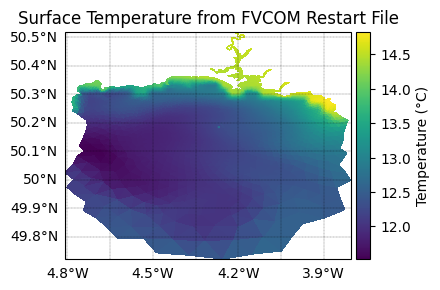

In [9]:
# Create an FVCOM plotter for our restart file
plotter = FVCOMPlotter(restart_file)

# Create a figure with geographic projection
fig, ax = create_figure(projection=ccrs.PlateCarree())

# Open the restart file and extract surface temperature
with Dataset(restart_file) as ds:
    temp = ds.variables['temp'][:]
    print(f"Temperature array shape: {temp.shape}")
    
    # Plot the surface temperature 
    # For restart files, dimensions are typically (time, siglay, node) or (siglay, node)
    if temp.ndim == 3:
        # (time, siglay, node) - use time=0, surface layer (last siglay index)
        temp_surface = temp[0, -1, :]
    elif temp.ndim == 2:
        # (siglay, node) - use surface layer (last siglay index)  
        temp_surface = temp[-1, :]
    else:
        # Fallback - use as is
        temp_surface = temp

plotter.plot_field(ax, temp_surface, add_colour_bar=True, cb_label='Temperature (°C)')
ax.set_title('Surface Temperature from FVCOM Restart File')

plt.show()

## Summary

Congratulations! You have successfully created an FVCOM restart file using CMEMS reanalysis data. Here's what we accomplished:

1. **Data Integration**: Combined high-quality oceanographic data from CMEMS with FVCOM's unstructured grid format
2. **Spatial Interpolation**: Converted data from CMEMS's regular grid to FVCOM's triangular mesh using the `CMEMSInterpolator` class
3. **Variable Mapping**: Correctly mapped between different variable naming conventions using the `fvcom_to_cmems_var_names` dictionary
4. **File Creation**: Generated a properly formatted NetCDF restart file ready for use in FVCOM

## Key Components of the PyFVCOM2 API

This tutorial demonstrates several important PyFVCOM2 components:

- **CMEMSReader**: Handles reading CMEMS NetCDF data files with flexible file input (single file or lists)
- **InterpolationCoordinates**: Unified coordinate handling for different grid positions (nodes vs elements)
- **CMEMSInterpolator**: Dedicated interpolator class for CMEMS data with automatic 2D/3D handling and variable name mapping
- **FVCOMReader**: Provides grid information and coordinate extraction from FVCOM files
- **write_restart**: Creates properly formatted FVCOM restart files

## API Notes

- The **CMEMSReader** accepts either a single file path or a list of file paths for flexibility
- **Interpolation coordinates** are obtained from the FVCOM grid and extended with time information
- **Variable name mapping** allows seamless translation between CMEMS and FVCOM naming conventions
- **Grid positioning** is handled automatically - variables are interpolated to the correct locations (nodes or elements)

This approach provides excellent separation of concerns and flexibility for different data sources and interpolation methods while maintaining ease of use for common workflows.